# **<p style="text-align: center;">GANs</p>**

### ■ __Overview__
In this notebook, we will investigate the training of two different kind of Generative Adversarial Networks (GANs). The first one is a Deep Convolutional Generative Adversarial Networks (DCGAN) for celebrity face generation. The second one is a Cycle Generative Adversarial Networks (CycleGAN) trained for a map translation.

In [10]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from data.dataloader import dataloader
from dcgan.generator import Generator
from dcgan.discriminator import Discriminator
from dcgan.methods import weight_init, training
from torchinfo import summary
from PIL import Image

print(torch.__version__)
print(torch.cuda.is_available())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2.9.1+cu128
True


### ■ **<a name="dataset">2. Dataset</a>** [(&#8593;)](#content)
In this second section, our focus shifts to creating the dataset essential for training the Graph Convolutional Network (GCN). The dataset is designed to provide different enzymes, the corresponding adjacency matrices (here encoded by an edge indices map), and the associated sign labels.

#### **Dataset Overview**

In [12]:
import os
from glob import glob
from data.dataset import CelebaDataset
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 100

noise_z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
train_loader, test_loader = dataloader('CelebA', batch_size=batch_size, img_size=128)

# all_imgs = sorted(glob(os.path.join("./data/celeba/img_align_celeba", '*.jpg')))
# print(len(all_imgs))
# print(all_imgs[:2])

Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /home/aki/gans/Generative-Adversarial-Networks/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 42.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /home/aki/gans/Generative-Adversarial-Networks/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 26.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /home/aki/gans/Generative-Adversarial-Networks/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 37.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /home/aki/gans/Generative-Adversarial-Networks/data/celeba/list_landmarks_align_celeba.txt
100%|██████████| 12.2M/12.2M [00:00<00:00, 16.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pY0NSMzRuSXJEVkk
To: /home/aki/gans/Generative-Ad

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


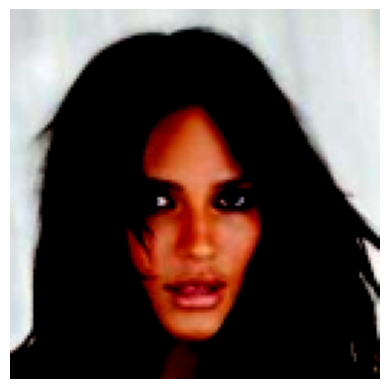

In [16]:
for batch in train_loader:
  plt.imshow(batch[0][2].permute(1, 2, 0))
  plt.axis('off')
  plt.plot()
  break

### ■ **<a name="model">3. DCGAN Model</a>** [(&#8593;)](#content)
No that the dataloaders are ready, we can build our GCN model to classify enzymes ! We define the GCN model by stacking a set of GCN layers to extract features, and an MLP layer to classify the extracted features into different classes.

In [17]:
generator = Generator(latent_dim=latent_dim, img_channels=3, num_features=128, bias=False)
discriminator = Discriminator(in_channels=3, num_features=128, bias=False)

# generator.apply(weight_init), discriminator.apply(weight_init

summary(generator, input_size=(batch_size, latent_dim, 1, 1)), summary(discriminator, input_size=(batch_size, 3, 128, 128))

(==========================================================================================
 Layer (type:depth-idx)                   Output Shape              Param #
 Generator                                [128, 3, 128, 128]        --
 ├─Sequential: 1-1                        [128, 3, 128, 128]        --
 │    └─GenBlock: 2-1                     [128, 1024, 2, 2]         --
 │    │    └─ConvTranspose2d: 3-1         [128, 1024, 2, 2]         1,638,400
 │    │    └─BatchNorm2d: 3-2             [128, 1024, 2, 2]         2,048
 │    │    └─ReLU: 3-3                    [128, 1024, 2, 2]         --
 │    └─GenBlock: 2-2                     [128, 512, 4, 4]          --
 │    │    └─ConvTranspose2d: 3-4         [128, 512, 4, 4]          8,388,608
 │    │    └─BatchNorm2d: 3-5             [128, 512, 4, 4]          1,024
 │    │    └─ReLU: 3-6                    [128, 512, 4, 4]          --
 │    └─GenBlock: 2-3                     [128, 256, 8, 8]          --
 │    │    └─ConvTranspose2d: 3

In [18]:
criterion = nn.BCEWithLogitsLoss()
optimizerG = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerD = torch.optim.Adam(discriminator.parameters(), lr=5e-5, betas=(0.5, 0.999))  # if it breaks try 5e-5

d_losses, g_losses = training(
    generator=generator,
    discriminator=discriminator,
    train_loader=train_loader,
    epochs=200,
    optimizerG=optimizerG,
    optimizerD=optimizerD,
    criterion=criterion,
    device=device,
    use_amp=True
)

Training Progress:   8%|▊         | 16/200 [2:36:29<29:59:36, 586.83s/it, train_D_loss=0.00571, train_G_loss=0.00566]


KeyboardInterrupt: 

In [19]:
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')

### ■ **<a name="eval">4. Model Evaluation</a>** [(&#8593;)](#content)
Now we evaluate our trained model. We plot both the validation loss and accuracy. We also plot the confusion matrix for different classes.

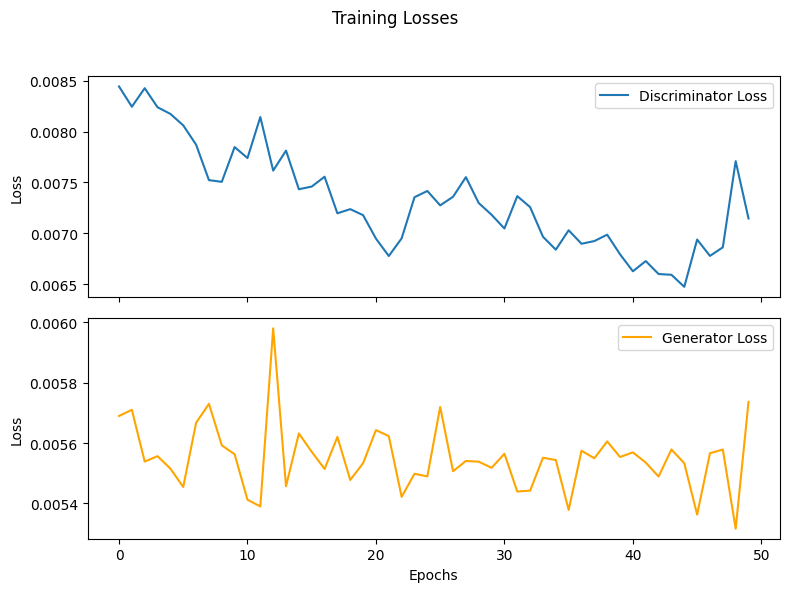

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.suptitle('Training Losses')

axes[0].plot(d_losses, label='Discriminator Loss')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(g_losses, label='Generator Loss', color='orange')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

torch.Size([16, 3, 32, 32])


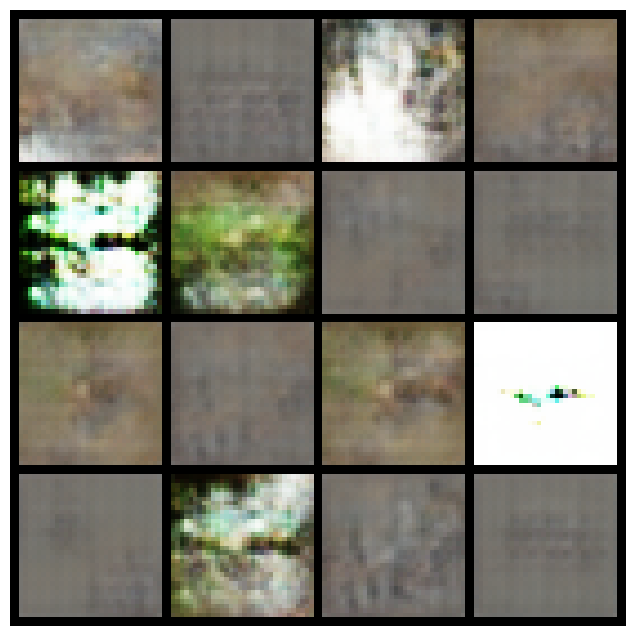

In [ ]:
example = torch.randn(16, latent_dim, 1, 1, device=device)
generator.eval()
with torch.no_grad():
    generator.to(device=device)
    generated_images = generator(example)
    print(generated_images.shape)

grid = torchvision.utils.make_grid(generated_images.cpu(), nrow=4, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()